In [1]:
# Import Libraries

import pandas as pd
import random
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
# Synthetic Dataset (2000 Reviews)

issue_templates = {
    "crash": [
        "App crashes every time I open it",
        "Application keeps crashing",
        "Frequent app crashes make it unusable"
    ],
    
    "billing": [
        "Wrong charges in my subscription",
        "Billing issue with premium plan",
        "Unexpected payment deducted"
    ],
    
    "performance": [
        "App is very slow",
        "Loading times are terrible",
        "Performance is sluggish"
    ],
    
    "login": [
        "Unable to login",
        "Login keeps failing",
        "Authentication issue in app"
    ],
    
    "ads": [
        "Too many ads in the app",
        "Advertisements are annoying",
        "Ad frequency is excessive"
    ]
}

reviews = []

for _ in range(2000):
    issue = random.choice(list(issue_templates.keys()))
    reviews.append(
        random.choice(issue_templates[issue])
    )

df = pd.DataFrame({
    "Review": reviews
})

display(df.head())

,Review
0,Performance is sluggish
1,Unable to login
2,Frequent app crashes make it unusable
3,Login keeps failing
4,Advertisements are annoying


In [3]:
# Text Preprocessing

def preprocess(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    return text

df["Cleaned"] = df["Review"].apply(preprocess)

In [4]:
# Convert Text to Numerical Form

vectorizer = CountVectorizer(
    stop_words='english'
)

X = vectorizer.fit_transform(
    df["Cleaned"]
)

In [5]:
# Apply LDA Topic Modeling

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [6]:
# Extract Top Keywords Per Topic

feature_names = vectorizer.get_feature_names_out()

topics = {}

for topic_idx, topic in enumerate(lda.components_):
    
    top_indices = topic.argsort()[-5:][::-1]
    
    keywords = [feature_names[i] for i in top_indices]
    
    topics[f"Topic {topic_idx+1}"] = keywords

topics

{'Topic 1': ['app', 'ads', 'crashes', 'unusable', 'frequent'],
 'Topic 2': ['unexpected', 'payment', 'deducted', 'performance', 'sluggish'],
 'Topic 3': ['issue', 'billing', 'premium', 'plan', 'app'],
 'Topic 4': ['keeps', 'app', 'application', 'crashing', 'slow'],
 'Topic 5': ['wrong', 'subscription', 'charges', 'advertisements', 'annoying']}

In [7]:
# Topic Frequency Distribution

topic_assignments = lda.transform(X).argmax(axis=1)

topic_counts = pd.Series(topic_assignments).value_counts().sort_index()

display(topic_counts)

0    407
1    546
2    139
3    639
4    269
Name: count, dtype: int64

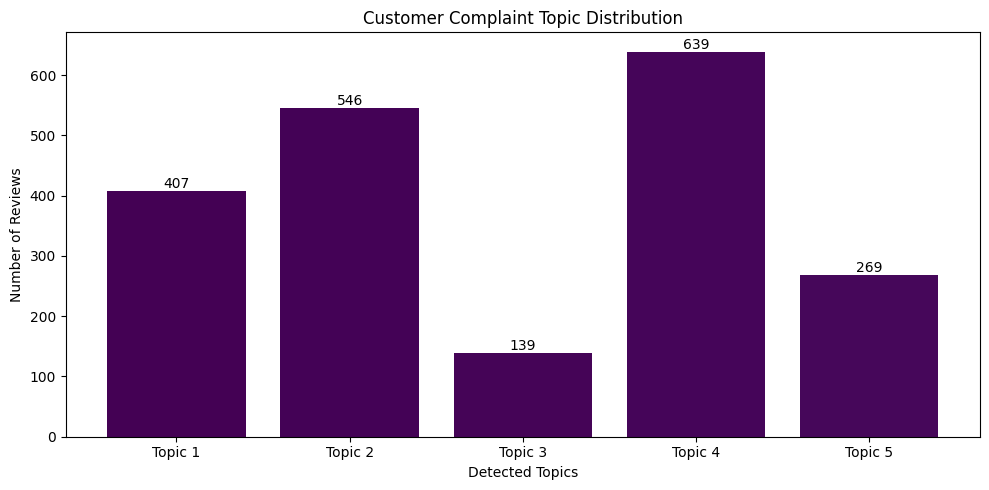

In [8]:
# Visualization of Topic Frequencies

plt.figure(figsize=(10,5))

bars = plt.bar(
    [f"Topic {i+1}" for i in topic_counts.index],
    topic_counts.values,
    color=plt.cm.viridis(range(len(topic_counts)))
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        str(height),
        ha='center'
    )

plt.title("Customer Complaint Topic Distribution")
plt.xlabel("Detected Topics")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [9]:
# Final Business Report

print("===== CUSTOMER DISSATISFACTION ANALYSIS REPORT =====\n")

print("Total Reviews Analyzed:", len(df))
print("Detected Major Complaint Themes:", len(topics))

print("\nTop Complaint Topics & Keywords:")
for topic, keywords in topics.items():
    print(f"{topic}: {', '.join(keywords)}")

print("\nRecommended Countermeasures:")
print("""
1. Improve App Stability:
   - Fix crash-related bugs immediately
   - Increase QA testing coverage

2. Resolve Billing Issues:
   - Audit subscription/payment system
   - Add billing transparency features

3. Optimize Performance:
   - Reduce app load times
   - Improve backend response speed

4. Fix Authentication/Login:
   - Review login infrastructure
   - Add fallback authentication methods

5. Reduce Advertisement Intrusion:
   - Lower ad frequency
   - Improve ad targeting/relevance
""")

===== CUSTOMER DISSATISFACTION ANALYSIS REPORT =====

Total Reviews Analyzed: 2000
Detected Major Complaint Themes: 5

Top Complaint Topics & Keywords:
Topic 1: app, ads, crashes, unusable, frequent
Topic 2: unexpected, payment, deducted, performance, sluggish
Topic 3: issue, billing, premium, plan, app
Topic 4: keeps, app, application, crashing, slow
Topic 5: wrong, subscription, charges, advertisements, annoying

Recommended Countermeasures:

1. Improve App Stability:
   - Fix crash-related bugs immediately
   - Increase QA testing coverage

2. Resolve Billing Issues:
   - Audit subscription/payment system
   - Add billing transparency features

3. Optimize Performance:
   - Reduce app load times
   - Improve backend response speed

4. Fix Authentication/Login:
   - Review login infrastructure
   - Add fallback authentication methods

5. Reduce Advertisement Intrusion:
   - Lower ad frequency
   - Improve ad targeting/relevance

